#### Data loading & inspection


In [136]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [83]:
df = pd.read_csv("C:\\Users\\lenovo\\Downloads\\car_prediction_data.csv")

In [84]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [85]:
df.shape

(301, 9)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [87]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## Data cleaning

In [88]:
numeric_cols = df.select_dtypes(include='number').columns


In [89]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [90]:
categorical_cols= df.select_dtypes(include='object').columns


In [91]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [92]:
df.drop_duplicates()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [93]:
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()


In [94]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [95]:
df.duplicated().sum()

2

In [96]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

In [97]:

for col in categorical_cols:
    df[col] = df[col].str.lower().str.strip()

In [98]:
for col in categorical_cols:
    print("\n", col)
    print(df[col].unique())


 Car_Name
['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'royal enfield thunder 500'
 'um renegade mojave' 'ktm rc200' 'bajaj dominar 400'
 'royal enfield classic 350' 'ktm rc390' 'hyosung gt250r'
 'royal enfield thunder 350' 'ktm 390 duke' 'mahindra mojo xt300'
 'bajaj pulsar rs200' 'royal enfield bullet 350'
 'royal enfield classic 500' 'bajaj avenger 220' 'bajaj avenger 150'
 'honda cb hornet 160r' 'yamaha fz s v 2.0' 'yamaha fz 16'
 'tvs apache rtr 160' 'bajaj pulsar 150' 'honda cbr 150' 'hero extreme'
 'bajaj avenger 220 dtsi' 'bajaj avenger 150 street' 'yamaha fz  v 2.0'
 'bajaj pulsar  ns 200' 'bajaj pulsar 220 f' 'tvs apache rtr 180'
 'hero passion x pro' 'bajaj pulsar ns 200' 'yamaha fazer'
 'honda activa 4g' 'tvs sport' 'honda dream yuga'
 'bajaj avenger street 220' 'hero

In [99]:
df.head

<bound method NDFrame.head of     Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    petrol   
1        sx4  2013           4.75           9.54       43000    diesel   
2       ciaz  2017           7.25           9.85        6900    petrol   
3    wagon r  2011           2.85           4.15        5200    petrol   
4      swift  2014           4.60           6.87       42450    diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    diesel   
297     brio  2015           4.00           5.90       60000    petrol   
298     city  2009           3.35          11.00       87934    petrol   
299     city  2017          11.50          12.50        9000    diesel   
300     brio  2016           5.30           5.90        5464    petrol   

    Seller_Type Transmission  Owner  
0        dealer       manual      0  
1    

## Feature engineering


In [100]:
df["Car_Age"] = 2026 - df["Year"]

In [101]:
df["Brand"] = df["Car_Name"].str.split().str[0]

In [102]:
df[["Car_Name", "Year", "Car_Age", "Brand"]].head()

,Car_Name,Year,Car_Age,Brand
0,ritz,2014,12,ritz
1,sx4,2013,13,sx4
2,ciaz,2017,9,ciaz
3,wagon r,2011,15,wagon
4,swift,2014,12,swift


## EDA : Chart

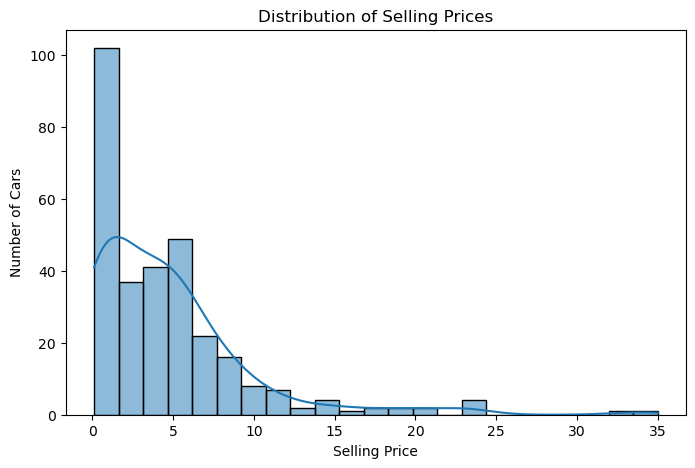

In [103]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()


### 1.Distribution of Selling Price
1.Most cars have low to medium selling prices.

2.Only a few cars have very high prices.

3.The distribution is right-skewed.

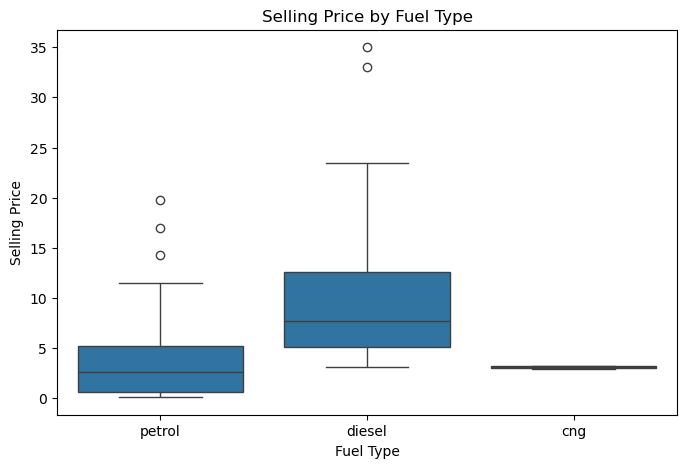

In [104]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()


### 2. Price vs Fuel Type
Diesel and Petrol cars show different selling-price ranges.

The box plot helps compare the median price and price variation for each fuel type.

Some fuel types have higher-priced cars and outliers.

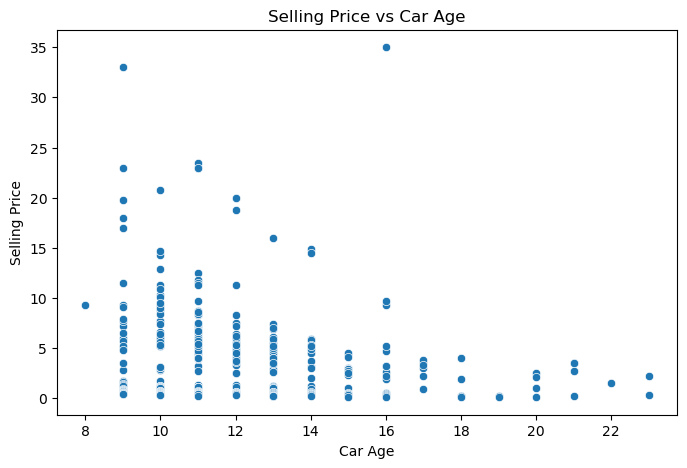

In [105]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

#### 3. Price vs Car Age
Newer cars generally have higher selling prices.
    
As car age increases, selling price tends to decrease.
    
This shows a negative relationship between car age and selling price.

## Encode categorical variables (One-Hot Encoding or Label Encoding)

In [106]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age',
       'Brand'],
      dtype='object')

In [107]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True
)

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Owner  Car_Age  \
0     ritz  2014           3.35           5.59       27000      0       12   
1      sx4  2013           4.75           9.54       43000      0       13   
2     ciaz  2017           7.25           9.85        6900      0        9   
3  wagon r  2011           2.85           4.15        5200      0       15   
4    swift  2014           4.60           6.87       42450      0       12   

   Brand  Fuel_Type_diesel  Fuel_Type_petrol  Seller_Type_individual  \
0   ritz             False              True                   False   
1    sx4              True             False                   False   
2   ciaz             False              True                   False   
3  wagon             False              True                   False   
4  swift              True             False                   False   

   Transmission_manual  
0                 True  
1                 True  
2                 True 

#### Interpretation: 
Categorical variables are converted into numerical values so that they can be used by machine-learning models.

## Correlation heatmap

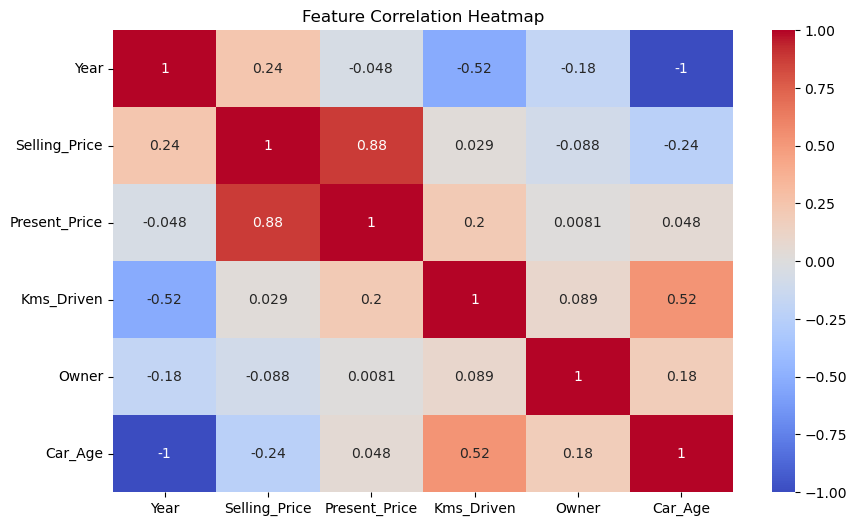

In [112]:
numeric_df = df.select_dtypes(include="number")

# Create correlation heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

## 
Positive correlation: When one feature increases, the other tends to increase.

Negative correlation: When one feature increases, the other tends to decrease.

Correlation near 0: There is little or no linear relationship between the two features.

## Train/test split

In [114]:
X = df.drop(["Selling_Price", "Car_Name"], axis=1)
y = df["Selling_Price"]


In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [116]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 10)
Testing data: (61, 10)


#### 80% data - Traning
20% data - Testing

###  Random Forest Regression

In [129]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [132]:
lr_pred = lr_model.predict(X_test)

In [134]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [135]:
rf_pred = rf_model.predict(X_test)

## Model Evaluation – MAE, RMSE and R² Score

In [141]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)


Linear Regression
MAE: 1.21622568212975
RMSE: 1.865155213552117
R² Score: 0.8489813024897876


In [142]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Regression")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)


Random Forest Regression
MAE: 0.6068672131147544
RMSE: 0.9076139515685987
R² Score: 0.9642395405961426


## Feature Importance Chart – Random Forest

In [143]:
importance = rf_model.feature_importances_

In [144]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

In [145]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

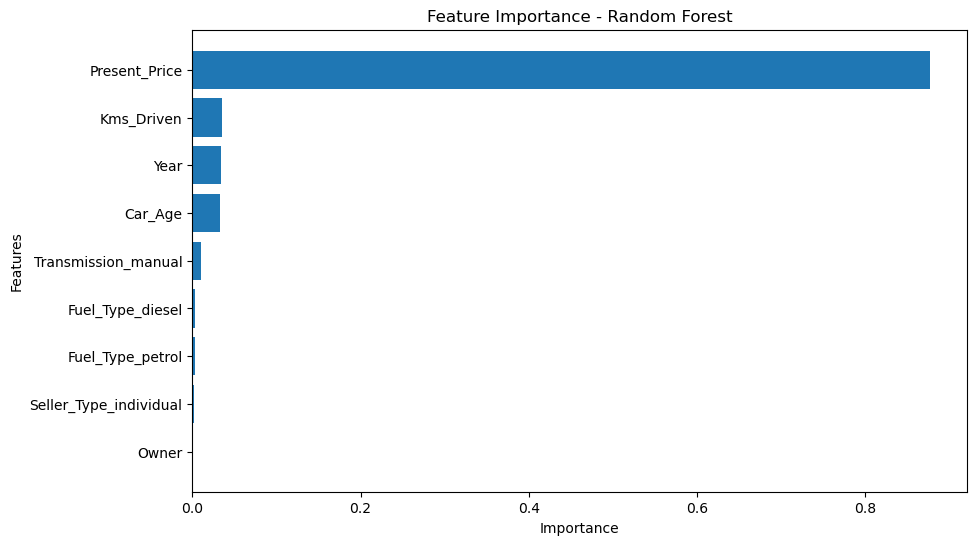

In [148]:
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

####
Higher importance means the feature has a greater effect on predicting selling price.

Present_Price and Kms_Driven may be among the important features.

 Features with low importance contribute less to the model's prediction.